<a href="https://colab.research.google.com/github/suryasridhar/regime-detection-and-optimization/blob/feature%2Fhmm/ETF_HMM_Regime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.decomposition import PCA
from scipy.optimize import minimize


In [82]:
start_date = '2002-09-01' 
end_date = '2025-12-01'
# We put ALL candidates in one big basket. 
# We don't tell the model which is "Growth" or "Defensive".

candidate_tickers = [
    'SPY',           # S&P 500 (Market)
    'QQQ',           # Nasdaq 100 (Growth)
    'XLK',           # Tech Sector (Growth)
    'XLE',           # Energy Sector (Inflation/Value)
    'XLV',           # Healthcare (Defensive)
    'XLP',           # Staples (Defensive)
    'TLT',           # 20+ Year Treasury (The Crisis Hedge) - Launched July 2002
    'IEF',           # 7-10 Year Treasury (Intermediate Safety) - Launched July 2002
    'LQD',           # Investment Grade Corp Bond (Credit Risk) - Launched July 2002
    'NEM',           # Gold Proxy (Newmont Mining) - Used because GLD didn't exist until 2004
]

In [83]:
universe_ohlcv = yf.download(candidate_tickers, start=start_date, end=end_date, group_by='column', auto_adjust=False)
universe_ohlcv = universe_ohlcv.dropna()

[*********************100%***********************]  10 of 10 completed


In [84]:
universe_ohlcv

Price       Adj Close                                                 \
Ticker            IEF         LQD        NEM         QQQ         SPY   
Date                                                                   
2002-09-03  43.245117   39.466499  19.381456   19.146935   57.446781   
2002-09-04  43.229847   39.612171  18.801407   19.223059   58.266712   
2002-09-05  43.402370   39.724270  19.481449   18.749449   57.772163   
2002-09-06  43.067501   39.455330  19.368116   19.324545   58.566063   
2002-09-09  43.006634   39.481426  19.788147   19.519053   58.995506   
...               ...         ...        ...         ...         ...   
2025-11-21  96.902924  110.510475  83.248055  590.070007  659.030029   
2025-11-24  97.052467  110.948853  86.279243  605.159973  668.729980   
2025-11-25  97.301735  111.257706  86.019997  608.890015  675.020020   
2025-11-26  97.381500  111.636307  90.519997  614.270020  679.679993   
2025-11-28  97.212006  111.447006  90.730003  619.250000  683.390015   

Price                                                                ...  \
Ticker            TLT        XLE         XLK        XLP         XLV  ...   
Date                                                                 ...   
2002-09-03  39.904404   5.837641    5.036759  11.715608   17.760475  ...   
2002-09-04  39.895348   5.824372    5.193459  11.810454   18.306736  ...   
2002-09-05  40.112862   5.834987    5.018105  11.804872   18.095057  ...   
2002-09-06  39.641521   5.930512    5.185995  11.804872   18.095057  ...   
2002-09-09  39.582596   5.922551    5.241959  12.039184   18.299911  ...   
...               ...        ...         ...        ...         ...  ...   
2025-11-21  89.181526  44.709999  136.600006  77.900002  154.610001  ...   
2025-11-24  89.689713  44.584999  139.854996  77.000000  155.259995  ...   
2025-11-25  89.918892  44.305000  140.229996  78.059998  158.770004  ...   
2025-11-26  90.317474  44.639999  141.889999  78.910004  158.419998  ...   
2025-11-28  89.889000  45.224998  143.110001  79.370003  157.649994  ...   

Price         Volume                                                      \
Ticker           IEF       LQD       NEM        QQQ        SPY       TLT   
Date                                                                       
2002-09-03    110700     49300   4460700   81828100   76586400    102100   
2002-09-04     77300   1690000   4369300   82717600   51099500     66300   
2002-09-05     57900    138300   5563300   91576600   67250900    648400   
2002-09-06     32200    224800   5734100   86008800   38622200    140000   
2002-09-09     88800     53600   6889700   72679500   33998400     83800   
...              ...       ...       ...        ...        ...       ...   
2025-11-21  12551100  41000500  10168500  103344200  123956200  41938600   
2025-11-24   6903900  28437900  16768900   60168100   80437900  30865700   
2025-11-25   9193400  47560900   8176100   57560900   81077100  36503300   
2025-11-26   7747100  24585400   7259100   42393600   71879600  34099000   
2025-11-28   7798000  25471200   4824600   23034400   49212000  40704300   

Price                                               
Ticker           XLE       XLK       XLP       XLV  
Date                                                
2002-09-03    177800   2919800     75000     55000  
2002-09-04   1249000   1838400     51700     87400  
2002-09-05    516600    785800     33500     31900  
2002-09-06    421000   5887800     65400     17700  
2002-09-09    206600   1398400     37500     29300  
...              ...       ...       ...       ...  
2025-11-21  39317200  44959000  22216000  25526100  
2025-11-24  33681800  20124800  17869400  17928400  
2025-11-25  29299000  21303400  18586300  17298600  
2025-11-26  26611000  13358800  13275100  12398900  
2025-11-28  16666600   6792200   8914300   8559700  

[5849 rows x 60 columns]

In [85]:
vix = yf.download('^VIX', start=start_date, end=end_date, progress=False, auto_adjust=False, multi_level_index=False)['Adj Close']
vix

Date
2002-09-03    39.970001
2002-09-04    37.439999
2002-09-05    38.860001
2002-09-06    36.330002
2002-09-09    36.450001
                ...    
2025-11-21    23.430000
2025-11-24    20.520000
2025-11-25    18.559999
2025-11-26    17.190001
2025-11-28    16.350000
Name: Adj Close, Length: 5849, dtype: float64

In [86]:
adj_close = universe_ohlcv['Adj Close']
high = universe_ohlcv['High']
low = universe_ohlcv['Low']
close = universe_ohlcv['Close']
open_p = universe_ohlcv['Open']
volume = universe_ohlcv['Volume']

In [87]:
def calculate_yang_zhang_vol(open_df, high_df, low_df, close_df, window=14):
    """
    Vectorized Yang-Zhang Volatility.
    Captures Overnight Risk + Open-to-Close Risk efficiently.
    """
    # 1. Overnight Volatility (Close to Open)
    # Shift Close to get previous day's close
    log_oc = np.log(open_df / close_df.shift(1))
    # Rolling Variance of overnight jumps
    vo = log_oc.rolling(window=window).var()
    
    # 2. Open-to-Close Volatility
    log_co = np.log(close_df / open_df)
    vc = log_co.rolling(window=window).var()
    
    # 3. Rogers-Satchell Volatility (Intraday Trend-Agnostic)
    # RS = mean( log(H/C)*log(H/O) + log(L/C)*log(L/O) )
    log_hc = np.log(high_df / close_df)
    log_ho = np.log(high_df / open_df)
    log_lc = np.log(low_df / close_df)
    log_lo = np.log(low_df / open_df)
    
    rs_term = (log_hc * log_ho) + (log_lc * log_lo)
    vrs = rs_term.rolling(window=window).mean()
    
    # 4. Combine (Standard weights for YZ)
    k = 0.34 / (1.34 + (window + 1) / (window - 1))
    
    # Yang-Zhang Variance
    yz_var = vo + k * vc + (1 - k) * vrs
    
    # Annualize
    return np.sqrt(yz_var) * np.sqrt(252)

In [88]:
print("Calculating Yang-Zhang Volatility (Overnight Gap Aware)...")
# We use YZ Volatility as our primary "Risk" input now
feat_vol = calculate_yang_zhang_vol(open_p, high, low, close, window=14)

Calculating Yang-Zhang Volatility (Overnight Gap Aware)...


In [89]:
print("Calculating Rolling Skewness & Kurtosis (Tail Risk)...")
returns = adj_close.pct_change()

# Rolling Skew (63-day / Quarterly window is standard to reduce noise)
# Negative Skew = "Crash Risk" (Small wins, big losses)
feat_skew = returns.rolling(window=63).skew()

# Rolling Kurtosis (Fat Tails)
# High Kurtosis = "Fragile Market" (Frequent 3-sigma events)
feat_kurt = returns.rolling(window=63).kurt()

Calculating Rolling Skewness & Kurtosis (Tail Risk)...


In [90]:
# --- RSI (14-Day) ---
delta = adj_close.diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
feat_rsi = 100 - (100 / (1 + rs))

In [91]:
print("Calculating Momentum (14-Day Returns)...")
feat_mom = adj_close.pct_change(14)

Calculating Momentum (14-Day Returns)...


In [92]:
typical_price = (high + low + close) / 3
money_flow = typical_price * volume
tp_diff = typical_price.diff()
pos_flow = (money_flow * (tp_diff > 0).astype(int)).rolling(14).sum()
neg_flow = (money_flow * (tp_diff < 0).astype(int)).rolling(14).sum()
mfi_ratio = pos_flow / neg_flow
feat_mfi = 100 - (100 / (1 + mfi_ratio))

In [93]:
features = pd.DataFrame(index=adj_close.index)

In [94]:
print("Constructing High-Dimensional Feature Matrix...")
df = pd.concat([
    feat_vol.add_suffix('_YZ_Vol'),
    feat_skew.add_suffix('_Skew'),
    feat_kurt.add_suffix('_Kurt'),
    feat_mom.add_suffix('_Mom'), # Added Momentum
    feat_rsi.add_suffix('_RSI'),
    feat_mfi.add_suffix('_MFI')
], axis=1)


Constructing High-Dimensional Feature Matrix...


In [95]:
df = df.dropna()
df

Ticker,IEF_YZ_Vol,LQD_YZ_Vol,NEM_YZ_Vol,QQQ_YZ_Vol,SPY_YZ_Vol,TLT_YZ_Vol,XLE_YZ_Vol,XLK_YZ_Vol,XLP_YZ_Vol,XLV_YZ_Vol,...,IEF_MFI,LQD_MFI,NEM_MFI,QQQ_MFI,SPY_MFI,TLT_MFI,XLE_MFI,XLK_MFI,XLP_MFI,XLV_MFI
Date,,,,,,,,,,,,,,,,,,,,,
2002-12-02,0.090562,0.088241,0.462555,0.376274,0.214882,0.127344,0.202728,0.377478,0.190291,0.185377,...,9.380073,25.080414,28.821286,82.012675,68.463985,16.273236,70.814399,86.995138,39.831979,17.993979
2002-12-03,0.092859,0.088162,0.413424,0.374356,0.215447,0.130117,0.203723,0.381091,0.175246,0.196602,...,11.812610,60.029953,41.105145,74.969410,61.919616,22.936932,75.627698,74.930493,47.191419,17.347102
2002-12-04,0.096094,0.084618,0.408400,0.372651,0.214126,0.132263,0.183831,0.397385,0.172764,0.184409,...,23.172738,53.472613,51.018603,63.966404,61.617434,27.549589,70.778042,67.466749,47.196955,21.232398
2002-12-05,0.093195,0.079016,0.397293,0.368434,0.210130,0.129101,0.179360,0.390043,0.165157,0.181553,...,34.095933,56.269823,53.043344,56.598229,55.292629,34.123029,65.894177,62.404187,40.091737,21.962561
2002-12-06,0.100664,0.086764,0.442213,0.378538,0.218570,0.140493,0.187939,0.394006,0.167109,0.190618,...,42.621596,58.053839,57.533776,50.073981,47.287760,44.744745,70.564992,58.216100,40.700488,19.709592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-21,0.041082,0.045234,0.475634,0.253188,0.186275,0.076793,0.225085,0.313322,0.115842,0.143848,...,40.732900,57.734246,42.907718,22.641934,27.927224,41.245952,56.034168,16.281587,54.664903,76.182656
2025-11-24,0.041327,0.043404,0.453587,0.249978,0.182793,0.078421,0.225680,0.307098,0.116279,0.144758,...,41.027728,54.842873,52.568825,28.731774,33.957702,41.857323,55.486726,21.499878,46.927342,76.643700
2025-11-25,0.039610,0.044276,0.451095,0.254501,0.186340,0.073425,0.225372,0.316848,0.114777,0.144302,...,47.251833,63.864217,52.567153,29.261332,34.259112,51.244380,50.122780,21.165291,54.281741,77.137375


In [96]:
print("Applying Rolling Normalization (252-Day Window)...")

rolling_mean = df.rolling(window=252).mean()
rolling_std = df.rolling(window=252).std()
epsilon = 1e-8

normalized_df = (df - rolling_mean) / (rolling_std + epsilon)
normalized_df = normalized_df.replace([np.inf, -np.inf], np.nan).dropna()

print("Applying 21-Day EMA Smoothing to Features (Anti-Chop)...")
normalized_df = normalized_df.ewm(span=21).mean()

print(f"Normalized & Smoothed Matrix Shape: {normalized_df.shape}")

Applying Rolling Normalization (252-Day Window)...
Applying 21-Day EMA Smoothing to Features (Anti-Chop)...
Normalized & Smoothed Matrix Shape: (5535, 60)


In [97]:
X_values = normalized_df.values
dates = normalized_df.index
returns_universe = np.log(adj_close / adj_close.shift(1)).reindex(dates)



In [98]:
dates

DatetimeIndex(['2003-12-01', '2003-12-02', '2003-12-03', '2003-12-04',
               '2003-12-05', '2003-12-08', '2003-12-09', '2003-12-10',
               '2003-12-11', '2003-12-12',
               ...
               '2025-11-14', '2025-11-17', '2025-11-18', '2025-11-19',
               '2025-11-20', '2025-11-21', '2025-11-24', '2025-11-25',
               '2025-11-26', '2025-11-28'],
              dtype='datetime64[ns]', name='Date', length=5535, freq=None)

In [99]:
# THE CUT-OFF POINT
# We use the first ~4 years (2006-2010) as "Burn-In" to initialize the model.
# We do NOT trade during this period.
initial_train_window = 1000
rebalance_step = 63 

# Print the Hard Line in the Sand
burn_in_end_date = dates[initial_train_window]
burn_in_end_date

Timestamp('2007-11-20 00:00:00')

In [100]:
print(f"1. In-Sample 'Burn-In' Period: {dates[0].date()} to {burn_in_end_date.date()}")

1. In-Sample 'Burn-In' Period: 2003-12-01 to 2007-11-20


In [101]:
def get_optimized_weights(returns_df, objective='sharpe', rf=0.0):

    num_assets = len(returns_df.columns)
    if num_assets == 0:
        return []
    if num_assets == 1:
        return np.array([1.0])

    # Annualized moments
    mean_rets = returns_df.mean() * 252
    cov_matrix = returns_df.cov() * 252

    # Constraints: fully invested, long-only
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_weights = np.array([1 / num_assets] * num_assets)

    def min_variance_func(weights):
        return np.dot(weights, np.dot(cov_matrix, weights.T))

    def sharpe_func(weights):
        port_ret = np.dot(mean_rets, weights)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return port_ret / port_vol if port_vol > 0 else 0.0

    def sortino_func(weights):
        # Portfolio daily returns
        port_rets = returns_df.values @ weights

        # Downside deviation (annualized)
        downside_rets = np.minimum(port_rets - rf / 252, 0)
        downside_vol = np.sqrt(np.mean(downside_rets**2)) * np.sqrt(252)

        port_ret = np.dot(mean_rets, weights) - rf

        return port_ret / downside_vol if downside_vol > 0 else 0.0


    if objective == 'min_var':
        result = minimize(
            min_variance_func,
            initial_weights,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

    elif objective == 'sortino':
        result = minimize(
            lambda w: -sortino_func(w),
            initial_weights,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

    else:  # sharpe
        result = minimize(
            lambda w: -sharpe_func(w),
            initial_weights,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

    return result.x

In [115]:
# =============================
# SETUP
# =============================
vol_cols = [i for i, col in enumerate(normalized_df.columns) if '_YZ_Vol' in col]

initial_train_window = 1000
rebalance_step = 63

portfolio_log_returns = []
benchmark_log_returns = []
regime_history = []
portfolio_dates = []

n_pca_components = 4
n_hmm_states = 2

pca = PCA(n_components=n_pca_components)

SWITCH_THRESHOLD = 0.9
current_regime = 0  # 0 = Low Vol (Green), 1 = High Vol (Red)

print(f"--- Starting Walk-Forward Loop (Hysteresis={SWITCH_THRESHOLD}) ---")

# =============================
# WALK-FORWARD LOOP
# =============================
for t in range(initial_train_window, len(X_values) - rebalance_step, rebalance_step):

    # =============================
    # 1. TRAIN PCA + HMM (PAST ONLY)
    # =============================
    X_train = X_values[:t]
    train_returns = returns_universe.iloc[:t]

    X_train_pca = pca.fit_transform(X_train)

    hmm = GaussianHMM(
        n_components=n_hmm_states,
        covariance_type="full",
        n_iter=100,
        random_state=42
    )
    hmm.fit(X_train_pca)

    train_states_raw = hmm.predict(X_train_pca)

    # =============================
    # 2. STATE ALIGNMENT (LOW VOL = 0)
    # =============================
    state_vols = [
        X_train[train_states_raw == s][:, vol_cols].mean()
        for s in range(n_hmm_states)
    ]

    map_dict = {
        old_id: new_id
        for new_id, old_id in enumerate(np.argsort(state_vols))
    }

    train_states = np.array([map_dict[s] for s in train_states_raw])

    # =============================
    # 3. BUILD STATE PLAYBOOK (TRAINING ONLY)
    # =============================
    state_playbook = {}

    for state in range(n_hmm_states):

        mask = (train_states == state)

        if mask.sum() < 20:
            state_playbook[state] = {'SPY': 1.0}
            continue

        regime_returns = train_returns[mask]

        # ---------- STATE 0: TAIL HARVESTING ----------
        if state == 0:

            market_strength = regime_returns.mean(axis=1)
            strong_days = market_strength > market_strength.quantile(0.60)
            filtered = regime_returns.loc[strong_days]

            if len(filtered) < 15:
                state_playbook[state] = {'SPY': 1.0}
                continue

            right_tail = filtered.quantile(0.90)
            left_tail = filtered.quantile(0.10).abs()
            skew = filtered.skew()

            tail_ratio = right_tail / (left_tail + 1e-6)

            tail_score = (
                0.5 * tail_ratio.rank(pct=True) +
                0.3 * right_tail.rank(pct=True) +
                0.2 * skew.rank(pct=True)
            )

            selected_assets = tail_score.nlargest(3).index.tolist()

            raw_weights = tail_score[selected_assets]
            weights = raw_weights ** 1.5
            weights = weights / weights.sum()

            state_playbook[state] = dict(zip(selected_assets, weights))

        # ---------- STATE 1: DEFENSIVE ----------
        else:
            avg_rets = regime_returns.mean()
            valid_assets = avg_rets[avg_rets > 0].index.tolist()

            if len(valid_assets) == 0:
                state_playbook[state] = {'IEF': 1.0}
            else:
                w = 1.0 / len(valid_assets)
                state_playbook[state] = {a: w for a in valid_assets}

    # =============================
    # 4. DAY-BY-DAY REGIME INFERENCE + EXECUTION
    # =============================
    end_idx = min(t + rebalance_step, len(X_values))
    X_test = X_values[t:end_idx]
    test_returns_slice = returns_universe.iloc[t:end_idx]

    X_test_pca = pca.transform(X_test)

    for i in range(len(X_test_pca) - 1):

        # Online regime inference
        X_so_far = np.vstack([X_train_pca, X_test_pca[:i+1]])
        probs = hmm.predict_proba(X_so_far)[-1]

        aligned_probs = np.zeros(n_hmm_states)
        for old_id, new_id in map_dict.items():
            aligned_probs[new_id] = probs[old_id]

        # Hysteresis
        prob_red = aligned_probs[1]
        if current_regime == 0 and prob_red > SWITCH_THRESHOLD:
            current_regime = 1
        elif current_regime == 1 and prob_red < (1 - SWITCH_THRESHOLD):
            current_regime = 0

        regime_history.append(current_regime)

        # ---------- EXECUTE NEXT DAY ----------
        next_day_returns = test_returns_slice.iloc[i + 1]
        weights = state_playbook[current_regime]

        daily_ret = sum(next_day_returns[tkr] * w for tkr, w in weights.items())

        if current_regime == 0:
            prob_green = aligned_probs[0]
            daily_ret *= 1.5 * (0.5 + prob_green)

        portfolio_log_returns.append(daily_ret)
        benchmark_log_returns.append(next_day_returns['SPY'])
        portfolio_dates.append(next_day_returns.name)

    if t % (rebalance_step * 4) == 0:
        print(f"Processed up to: {returns_universe.index[t].date()}")

# =============================
# RESULTS DATAFRAME
# =============================
results = pd.DataFrame(
    {
        'Strategy': np.exp(np.cumsum(portfolio_log_returns)),
        'Benchmark': np.exp(np.cumsum(benchmark_log_returns)),
        'Regime': regime_history
    },
    index=pd.DatetimeIndex(portfolio_dates)
)

--- Starting Walk-Forward Loop (Hysteresis=0.9) ---


In [116]:
results

,Strategy,Benchmark,Regime
2007-11-21,0.990295,0.979535,1
2007-11-23,0.999674,0.996474,1
2007-11-26,0.992545,0.974488,1
2007-11-27,0.995528,0.985689,1
2007-11-28,1.010761,1.017215,1
...,...,...,...
2025-08-26,63.297952,7.219193,0
2025-08-27,63.723766,7.235642,0
2025-08-28,64.553071,7.261267,0
2025-08-29,63.012639,7.217963,0


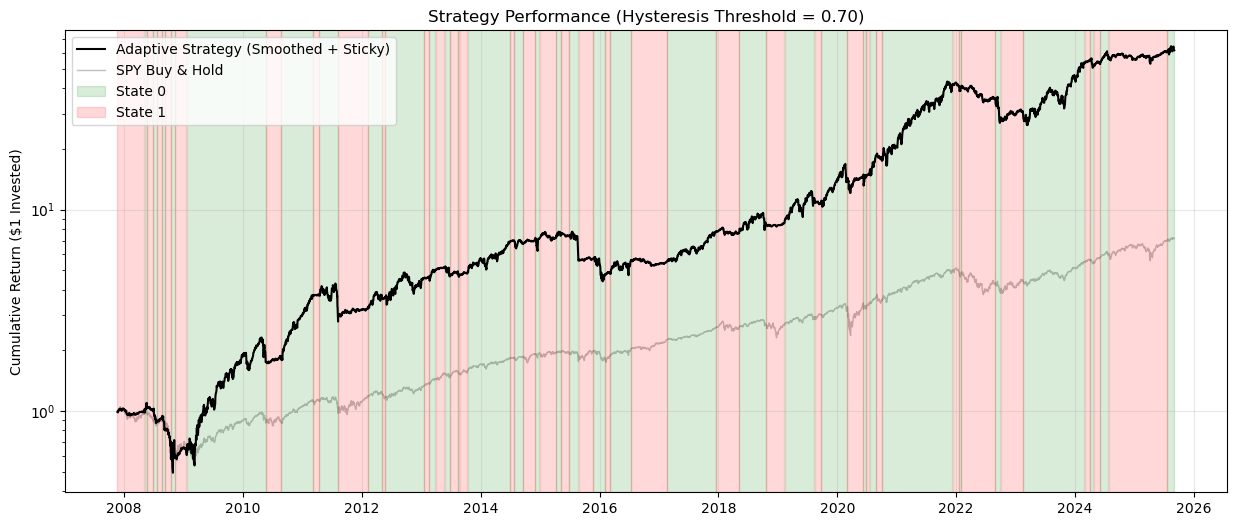

In [117]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(results['Strategy'], label='Adaptive Strategy (Smoothed + Sticky)', color='black', linewidth=1.5, zorder=2)
ax.plot(results['Benchmark'], label='SPY Buy & Hold', color='gray', alpha=0.5, linewidth=1, zorder=1)

state_colors = {0: 'green', 1: 'red'}
y_min, y_max = ax.get_ylim()
for state in range(n_hmm_states):
    mask = (results['Regime'] == state)
    ax.fill_between(results.index, 0, 100000, where=mask, 
                    color=state_colors.get(state, 'blue'), alpha=0.15, 
                    transform=ax.get_xaxis_transform(), label=f'State {state}')

ax.set_yscale('log')
ax.set_title("Strategy Performance (Hysteresis Threshold = 0.70)")
ax.set_ylabel("Cumulative Return ($1 Invested)")
ax.set_ylim(results['Strategy'].min() * 0.8, results['Strategy'].max() * 1.2)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.show()

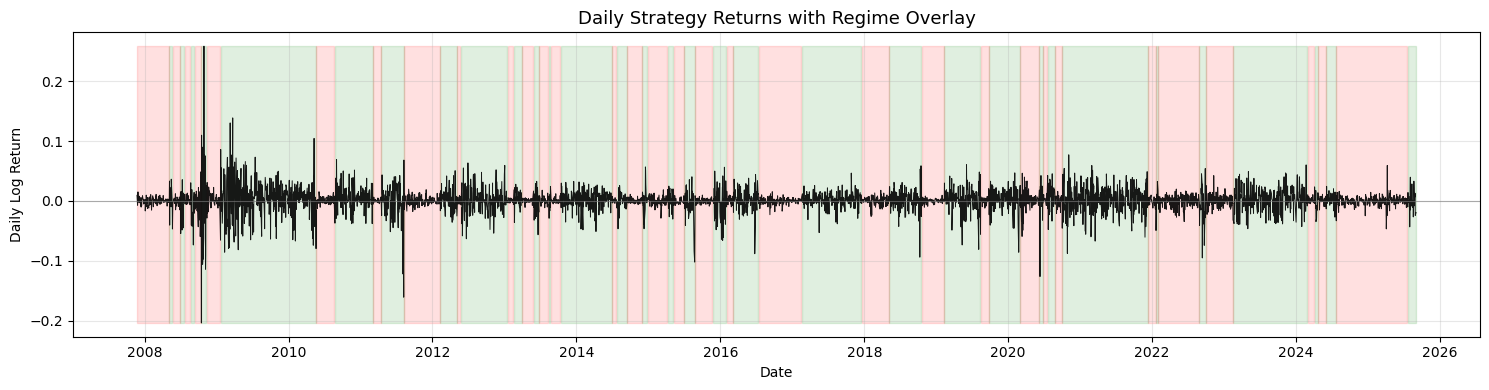

In [119]:
# Recover daily log returns from cumulative series
strategy_daily_returns = np.diff(np.log(results['Strategy']))
dates_daily = results.index[1:]

fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(
    dates_daily,
    strategy_daily_returns,
    color='black',
    linewidth=0.7,
    alpha=0.9,
    label='Daily Log Returns'
)

# Regime shading (shifted by 1 due to diff)
for state in np.unique(results['Regime'].values[1:]):
    mask = results['Regime'].values[1:] == state
    ax.fill_between(
        dates_daily,
        strategy_daily_returns.min(),
        strategy_daily_returns.max(),
        where=mask,
        color=state_colors.get(state, 'blue'),
        alpha=0.12
    )

# Formatting
ax.axhline(0, color='gray', linewidth=0.8, alpha=0.6)
ax.set_title("Daily Strategy Returns with Regime Overlay", fontsize=13)
ax.set_ylabel("Daily Log Return")
ax.set_xlabel("Date")

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

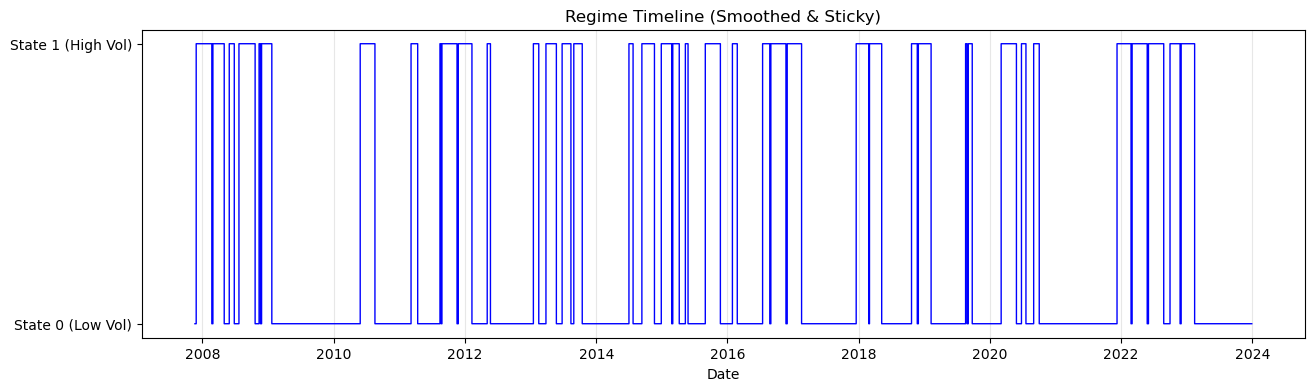

In [80]:
# PLOT 2: REGIME TIMELINE (DE-BARCODED)
plt.figure(figsize=(15, 4))
plt.plot(results.index, results['Regime'], drawstyle='steps-post', color='blue', linewidth=1)
plt.yticks([0, 1], ['State 0 (Low Vol)', 'State 1 (High Vol)'])
plt.title("Regime Timeline (Smoothed & Sticky)")
plt.xlabel("Date")
plt.grid(True, axis='x', alpha=0.3)
plt.show()

In [120]:
TRADING_DAYS = 252

# =============================
# DAILY LOG RETURNS
# =============================
strategy_rets = np.diff(np.log(results['Strategy'].values))
benchmark_rets = np.diff(np.log(results['Benchmark'].values))

# Align dates
rets_df = pd.DataFrame({
    "Strategy": strategy_rets,
    "Benchmark": benchmark_rets
}, index=results.index[1:])


# =============================
# SORTINO RATIO
# =============================
def sortino_ratio(returns, periods=252):
    downside = returns[returns < 0]
    if len(downside) == 0:
        return np.nan
    return np.sqrt(periods) * returns.mean() / downside.std(ddof=1)


strategy_sortino = sortino_ratio(rets_df["Strategy"].values)
benchmark_sortino = sortino_ratio(rets_df["Benchmark"].values)


# =============================
# MAX DRAWDOWN
# =============================
def max_drawdown_from_equity(equity_curve):
    running_max = np.maximum.accumulate(equity_curve)
    drawdowns = equity_curve / running_max - 1.0
    return drawdowns.min()


strategy_max_dd = max_drawdown_from_equity(results["Strategy"].values)
benchmark_max_dd = max_drawdown_from_equity(results["Benchmark"].values)


# =============================
# OUTPUT
# =============================
summary = pd.DataFrame({
    "Metric": ["Sortino Ratio", "Max Drawdown"],
    "Strategy": [strategy_sortino, strategy_max_dd],
    "Benchmark": [benchmark_sortino, benchmark_max_dd]
})

print(summary)

          Metric  Strategy  Benchmark
0  Sortino Ratio  0.906083   0.680045
1   Max Drawdown -0.550136  -0.493155


In [125]:
# =============================
# METRICS FROM 2009 ONWARD
# =============================

TRADING_DAYS = 252
START_DATE = "2009-01-01"

# -----------------------------
# FILTER RESULTS
# -----------------------------
results_2009 = results.loc[results.index >= START_DATE].copy()

# -----------------------------
# DAILY LOG RETURNS
# -----------------------------
strategy_rets = np.diff(np.log(results_2009["Strategy"].values))
benchmark_rets = np.diff(np.log(results_2009["Benchmark"].values))

rets_df = pd.DataFrame(
    {
        "Strategy": strategy_rets,
        "Benchmark": benchmark_rets
    },
    index=results_2009.index[1:]
)

strategy_sortino = sortino_ratio(rets_df["Strategy"].values)
benchmark_sortino = sortino_ratio(rets_df["Benchmark"].values)

strategy_max_dd = max_drawdown_from_equity(results_2009["Strategy"].values)
benchmark_max_dd = max_drawdown_from_equity(results_2009["Benchmark"].values)

# -----------------------------
# SUMMARY TABLE
# -----------------------------
summary = pd.DataFrame({
    "Metric": ["Sortino Ratio (2009+)", "Max Drawdown (2009+)"],
    "Strategy": [strategy_sortino, strategy_max_dd],
    "Benchmark": [benchmark_sortino, benchmark_max_dd]
})

print(summary)

                  Metric  Strategy  Benchmark
0  Sortino Ratio (2009+)  1.144641   0.957756
1   Max Drawdown (2009+) -0.433280  -0.306004
